In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path to dataset files:", path)

# Kiểm tra cấu trúc thư mục (tối đa 3 cấp)
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level <= 3:
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")
        if level == 3:
            print(f"{'  ' * (level+1)}... ({len(files)} files)")

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog
cat-and-dog/
  test_set/
    test_set/
      dogs/
        ... (1013 files)
      cats/
        ... (1012 files)
  training_set/
    training_set/
      dogs/
        ... (4006 files)
      cats/
        ... (4001 files)


In [ ]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (64, 64)

def load_images_from_folder(folder_path, label):
    photos = []
    labels = []
    for filename in os.listdir(folder_path):
        filepath = os.path.join(folder_path, filename)
        try:
            img = load_img(filepath, target_size=IMG_SIZE)
            img_array = img_to_array(img)
            photos.append(img_array)
            labels.append(label)
        except Exception as e:
            pass
    return photos, labels

# Sửa đường dẫn: thêm 1 cấp thư mục so với ban đầu
train_cats_photos, train_cats_labels = load_images_from_folder(
    os.path.join(path, 'training_set/training_set/cats'), label=0
)
train_dogs_photos, train_dogs_labels = load_images_from_folder(
    os.path.join(path, 'training_set/training_set/dogs'), label=1
)

test_cats_photos, test_cats_labels = load_images_from_folder(
    os.path.join(path, 'test_set/test_set/cats'), label=0
)
test_dogs_photos, test_dogs_labels = load_images_from_folder(
    os.path.join(path, 'test_set/test_set/dogs'), label=1
)

# Gộp lại
X_train = np.array(train_cats_photos + train_dogs_photos)
y_train = np.array(train_cats_labels + train_dogs_labels)

X_test = np.array(test_cats_photos + test_dogs_photos)
y_test = np.array(test_cats_labels + test_dogs_labels)

print(f"X_train shape: {X_train.shape}")  # kỳ vọng (8007, 64, 64, 3)
print(f"X_test shape:  {X_test.shape}")   # kỳ vọng (2025, 64, 64, 3)
print(f"Train - Cats: {sum(y_train==0)}, Dogs: {sum(y_train==1)}")
print(f"Test  - Cats: {sum(y_test==0)},  Dogs: {sum(y_test==1)}")

X_train shape: (8005, 64, 64, 3)
X_test shape:  (2023, 64, 64, 3)
Train - Cats: 4000, Dogs: 4005
Test  - Cats: 1011,  Dogs: 1012


In [ ]:
# Flatten: (N, 64, 64, 3) -> (N, 12288)
X_train_flat = X_train.reshape(len(X_train), -1).astype('float32') / 255.0
X_test_flat  = X_test.reshape(len(X_test),  -1).astype('float32') / 255.0

print(f"X_train_flat shape: {X_train_flat.shape}")  # (N, 12288)

X_train_flat shape: (8005, 12288)


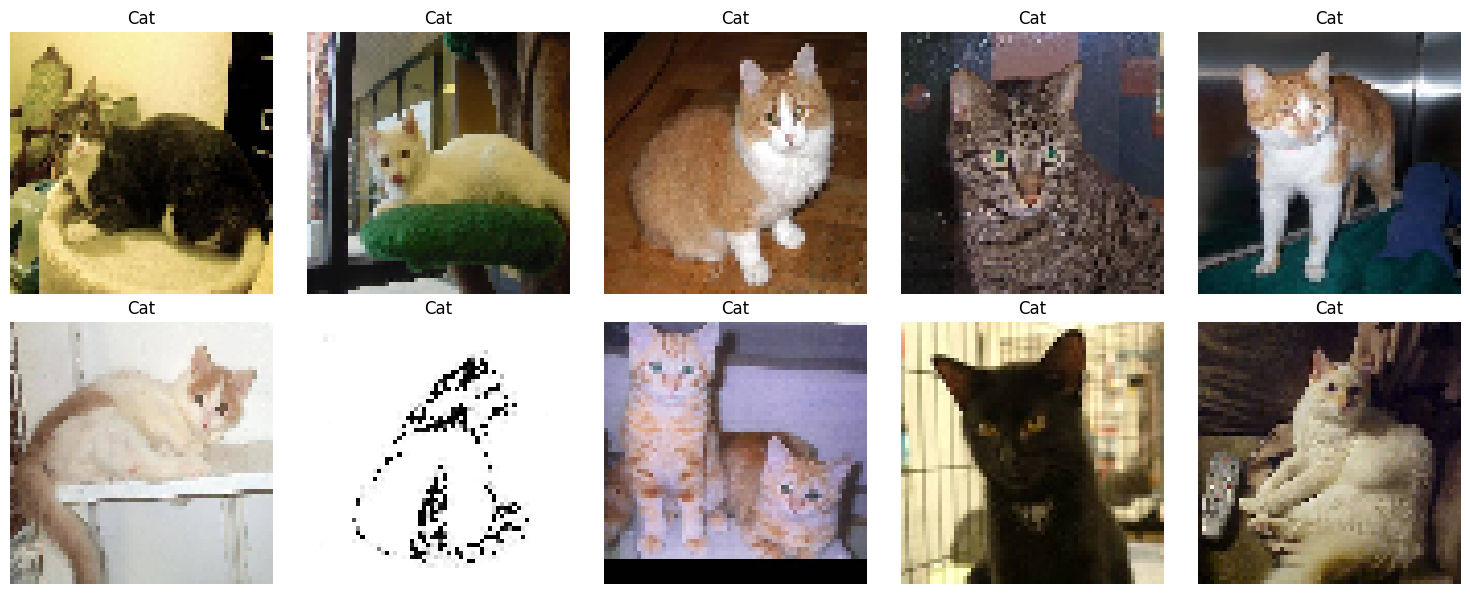

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train[i].astype('uint8'))
    axes[i].set_title('Cat' if y_train[i] == 0 else 'Dog')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization

input_dim = X_train_flat.shape[1]  # 12288

model = Sequential([
    Dense(1024, activation='relu', kernel_initializer='he_uniform', input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.4),

    Dense(512, activation='relu', kernel_initializer='he_uniform'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu', kernel_initializer='he_uniform'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_initializer='he_uniform'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')  # Binary: cat=0, dog=1
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',   # Binary classification
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │    12,583,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,280,257 (50.66 MB)

 Trainable params: 13,276,673 (50.65 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
from sklearn.utils import shuffle

# Shuffle data trước khi train
X_train_flat, y_train = shuffle(X_train_flat, y_train, random_state=42)

model_catdog = Sequential([
    Dense(2048, activation='relu', kernel_initializer='he_uniform', input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1024, activation='relu', kernel_initializer='he_uniform'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(512, activation='relu', kernel_initializer='he_uniform'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu', kernel_initializer='he_uniform'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_catdog.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # lr nhỏ hơn
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

history = model_catdog.fit(
    X_train_flat, y_train,
    validation_split=0.2,   # tăng lên 20% để val set ổn định hơn
    epochs=50,
    batch_size=64,           # tăng batch size để gradient ổn định hơn
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 69s 620ms/step - accuracy: 0.5387 - loss: 0.8682 - val_accuracy: 0.5053 - val_loss: 1.4204 - learning_rate: 5.0000e-04
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 82s 628ms/step - accuracy: 0.5489 - loss: 0.7840 - val_accuracy: 0.5615 - val_loss: 0.7763 - learning_rate: 5.0000e-04
Epoch 3/50
 52/101 ━━━━━━━━━━━━━━━━━━━━ 28s 579ms/step - accuracy: 0.5553 - loss: 0.7557

In [ ]:
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]

history = model.fit(
    X_train_flat, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 62s 256ms/step - accuracy: 0.5451 - loss: 0.7985 - val_accuracy: 0.3508 - val_loss: 0.9158 - learning_rate: 0.0010
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 57s 253ms/step - accuracy: 0.5672 - loss: 0.7253 - val_accuracy: 0.3508 - val_loss: 0.8728 - learning_rate: 0.0010
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 83s 256ms/step - accuracy: 0.5948 - loss: 0.6823 - val_accuracy: 0.5218 - val_loss: 0.7435 - learning_rate: 0.0010
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 56s 250ms/step - accuracy: 0.6052 - loss: 0.6643 - val_accuracy: 0.3895 - val_loss: 0.8222 - learning_rate: 0.0010
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 57s 253ms/step - accuracy: 0.6219 - loss: 0.6496 - val_accuracy: 0.4295 - val_loss: 0.8116 - learning_rate: 0.0010
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.6465 - loss: 0.6318
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
226/226 ━━━━━━━━━━━━━━━━━━━━ 56s 249ms/step - accuracy: 0.637

Test accuracy: 57.34%
Test loss:     0.8987


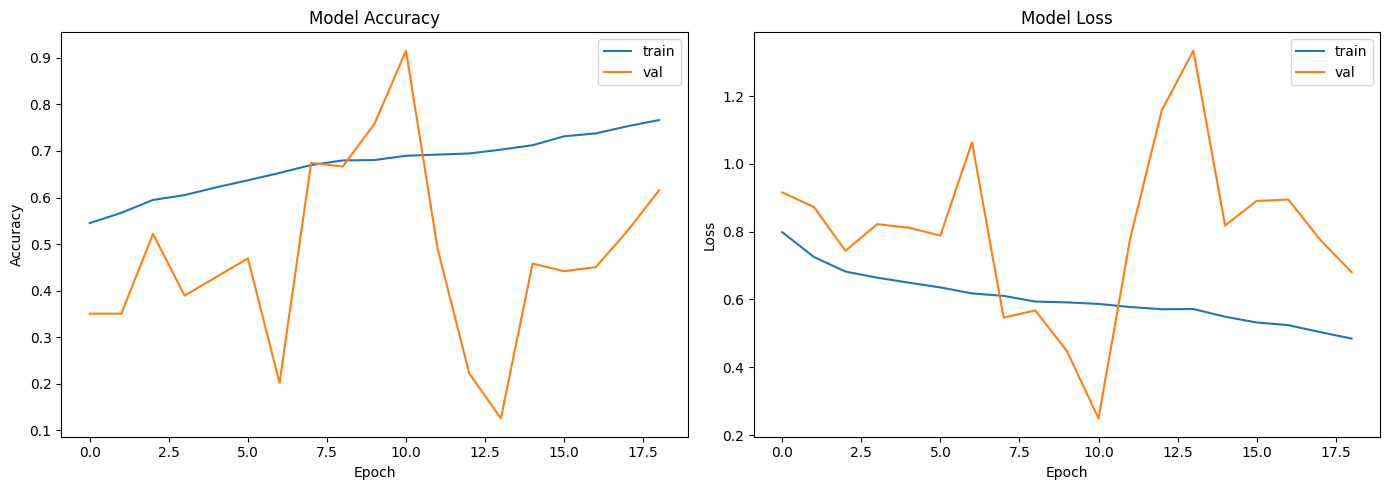

In [ ]:
# Đánh giá trên test set
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss:     {test_loss:.4f}")

# Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()